In [2]:
import pandas as pd
import numpy as np

# 1. Load the datasets
# Assuming the notebook is inside the /notebooks folder, so we use '../data/'
nyt_df = pd.read_csv('../data/cleaned_priors.csv')
wt_df = pd.read_csv('../data/wordletools_priors.csv')

# 2. Merge datasets on the 'word' column
# This guarantees rows are perfectly aligned for comparison
df = pd.merge(nyt_df, wt_df, on='word', suffixes=('_nyt', '_wt'))

# 3. Normalize the NYT priors
# The NYT max is ~1.0, while WordleTools max is ~0.58. 
df['prior_nyt_scaled'] = df['prior_nyt'] * 0.58

# 4. Check for equality within a floating-point tolerance bound
# 1e-4 allows for a 0.01% rounding difference
TOLERANCE = 1e-4  
df['diff'] = np.abs(df['prior_nyt_scaled'] - df['prior_wt'])
df['is_equal'] = df['diff'] <= TOLERANCE

# 5. Calculate statistics
total_words = len(df)
equal_count = df['is_equal'].sum()
different_count = total_words - equal_count

print("=== PRIORS COMPARISON SUMMARY ===")
print(f"Total words analyzed: {total_words}")
print(f"Equal priors (within {TOLERANCE} tolerance): {equal_count}")
print(f"Different priors: {different_count}")
print("=================================\n")

# 6. Extract and display the mismatches
if different_count > 0:
    mismatches = df[~df['is_equal']].copy()
    
    # Sort by the largest absolute difference so the most egregious outliers are at the top
    mismatches = mismatches.sort_values(by='diff', ascending=False)
    
    print(f"List of differing priors (Largest differences first, capped at 100):")
    
    # Jupyter's display() renders DataFrames beautifully as HTML tables
    display(mismatches[['word', 'prior_nyt_scaled', 'prior_wt', 'diff']].head(100))
else:
    print("All priors match perfectly within the tolerance bound!")

=== PRIORS COMPARISON SUMMARY ===
Total words analyzed: 14855
Equal priors (within 0.0001 tolerance): 13405
Different priors: 1450

List of differing priors (Largest differences first, capped at 100):


,word,prior_nyt_scaled,prior_wt,diff
14474,wreck,0.000452,0.58,0.579548
14333,wield,0.000452,0.58,0.579548
14332,width,0.000452,0.58,0.579548
14309,whole,0.000452,0.58,0.579548
14305,white,0.000452,0.58,0.579548
...,...,...,...,...
11410,sepia,0.000452,0.58,0.579548
11364,segue,0.000452,0.58,0.579548
11267,scoop,0.000452,0.58,0.579548
11248,scene,0.000452,0.58,0.579548


In [3]:
# 1. Load the past answers list safely
try:
    past_answers_df = pd.read_csv('../data/past_answers.csv', header=None)
    
    # Flatten the entire DataFrame into a single list of strings
    all_values = past_answers_df.values.flatten()
    all_strings = [str(v).strip().lower() for v in all_values]
    
    # Filter for ONLY valid 5-letter alphabetical words to guarantee we grab the right data
    past_answers = set(word for word in all_strings if len(word) == 5 and word.isalpha())
    
    print(f"Extracted {len(past_answers)} valid 5-letter past answers from file.")
except FileNotFoundError:
    print("Error: Could not find '../data/past_answers.csv'")
    past_answers = set()

# 2. Flag the mismatches
if different_count > 0:
    mismatches['is_past_answer'] = mismatches['word'].isin(past_answers)
    
    # Calculate how many of the differing priors are explained by being past answers
    explained_count = mismatches['is_past_answer'].sum()
    unexplained_count = different_count - explained_count
    
    print("\n=== PAST ANSWERS ANALYSIS ===")
    print(f"Total Mismatches: {different_count}")
    print(f"Mismatches explained by 'Used Word Penalty': {explained_count} ({(explained_count/different_count)*100:.1f}%)")
    print(f"Unexplained mismatches: {unexplained_count}")
    print("=============================\n")
    
    # 3. Check what the unexplained words are (if any)
    if unexplained_count > 0:
        print("Here are the top unexplained mismatched words:")
        unexplained_df = mismatches[~mismatches['is_past_answer']].copy()
        display(unexplained_df[['word', 'prior_nyt_scaled', 'prior_wt', 'diff']].head(20))
    else:
        print("All mismatched priors are perfectly explained by the past answers penalty!")

Extracted 1838 valid 5-letter past answers from file.

=== PAST ANSWERS ANALYSIS ===
Total Mismatches: 1450
Mismatches explained by 'Used Word Penalty': 1450 (100.0%)
Unexplained mismatches: 0

All mismatched priors are perfectly explained by the past answers penalty!


In [4]:
# 1. Load the past answers with explicit columns
try:
    history_df = pd.read_csv('../data/past_answers.csv')
    
    # Ensure the solution column is clean for merging
    history_df['solution'] = history_df['solution'].astype(str).str.strip().str.lower()
    print(f"Loaded {len(history_df)} past answers with dates.")
    
except Exception as e:
    print(f"Error loading past answers: {e}")

# 2. Merge with the main comparison dataframe (assuming 'df' is still in memory)
timeline_df = pd.merge(history_df, df, left_on='solution', right_on='word', how='inner')

# Sort to guarantee chronological order
timeline_df = timeline_df.sort_values(by='game_num').reset_index(drop=True)

print("\n=== CHRONOLOGICAL REGIONS ===")
print("Tracking contiguous blocks where NYT and WordleTools priors agree or disagree...\n")

if not timeline_df.empty:
    regions = []
    
    # Initialize tracking variables for the first row
    current_state = timeline_df.loc[0, 'is_equal']
    start_idx = 0
    
    # Iterate through the timeline to find region boundaries
    for i in range(1, len(timeline_df)):
        if timeline_df.loc[i, 'is_equal'] != current_state:
            # The state changed, so save the completed region
            regions.append({
                'state': "MATCH" if current_state else "MISMATCH",
                'start_game': timeline_df.loc[start_idx, 'game_num'],
                'end_game': timeline_df.loc[i-1, 'game_num'],
                'start_date': timeline_df.loc[start_idx, 'date'],
                'end_date': timeline_df.loc[i-1, 'date'],
                'count': i - start_idx
            })
            # Reset for the new region
            current_state = timeline_df.loc[i, 'is_equal']
            start_idx = i
            
    # Append the final region
    final_idx = len(timeline_df) - 1
    regions.append({
        'state': "MATCH" if current_state else "MISMATCH",
        'start_game': timeline_df.loc[start_idx, 'game_num'],
        'end_game': timeline_df.loc[final_idx, 'game_num'],
        'start_date': timeline_df.loc[start_idx, 'date'],
        'end_date': timeline_df.loc[final_idx, 'date'],
        'count': final_idx - start_idx + 1
    })
    
    # Format and print the regions
    for r in regions:
        print(f"Games {r['start_game']:>4} to {r['end_game']:>4} "
              f"({r['start_date']} to {r['end_date']}) "
              f"| Status: {r['state']:<8} "
              f"| Count: {r['count']}")
else:
    print("No matching data found to build timeline.")

Loaded 1856 past answers with dates.

=== CHRONOLOGICAL REGIONS ===
Tracking contiguous blocks where NYT and WordleTools priors agree or disagree...

Games    0 to    0 (2021-06-19 to 2021-06-19) | Status: MISMATCH | Count: 1
Games    1 to    3 (2021-06-20 to 2021-06-22) | Status: MATCH    | Count: 3
Games    4 to    4 (2021-06-23 to 2021-06-23) | Status: MISMATCH | Count: 1
Games    5 to   14 (2021-06-24 to 2021-07-03) | Status: MATCH    | Count: 10
Games   15 to   15 (2021-07-04 to 2021-07-04) | Status: MISMATCH | Count: 1
Games   16 to   50 (2021-07-05 to 2021-08-08) | Status: MATCH    | Count: 35
Games   51 to   51 (2021-08-09 to 2021-08-09) | Status: MISMATCH | Count: 1
Games   52 to   56 (2021-08-10 to 2021-08-14) | Status: MATCH    | Count: 5
Games   57 to   57 (2021-08-15 to 2021-08-15) | Status: MISMATCH | Count: 1
Games   58 to   58 (2021-08-16 to 2021-08-16) | Status: MATCH    | Count: 1
Games   59 to   59 (2021-08-17 to 2021-08-17) | Status: MISMATCH | Count: 1
Games   60 t

In [5]:
import numpy as np
import pandas as pd

# 1. Identify words that have been used as a solution more than once
repeated_words = timeline_df[timeline_df.duplicated(subset=['solution'], keep=False)]['solution'].unique()

print(f"Found {len(repeated_words)} distinct words that have repeated in Wordle history.\n")

# 2. Create a modified timeline where repeated words inherit their region's context
tidied_timeline = timeline_df.copy()

# FIX: Coerce the column to 'object' dtype first so it can safely hold None
tidied_timeline['is_equal'] = tidied_timeline['is_equal'].astype(object)

# Set the state of repeated words to None so they don't break continuity
tidied_timeline.loc[tidied_timeline['solution'].isin(repeated_words), 'is_equal'] = None

# Forward-fill and backward-fill to seamlessly adopt the neighbor's state, then restore bool dtype
tidied_timeline['is_equal'] = tidied_timeline['is_equal'].ffill().bfill().astype(bool)

print("=== SEAMLESS CHRONOLOGICAL REGIONS ===")
print("Tracking continuous blocks with repeated words perfectly blended into their environments...\n")

if not tidied_timeline.empty:
    tidied_regions = []
    
    current_state = tidied_timeline.loc[0, 'is_equal']
    start_idx = 0
    
    for i in range(1, len(tidied_timeline)):
        if tidied_timeline.loc[i, 'is_equal'] != current_state:
            tidied_regions.append({
                'state': "MATCH" if current_state else "MISMATCH",
                'start_game': tidied_timeline.loc[start_idx, 'game_num'],
                'end_game': tidied_timeline.loc[i-1, 'game_num'],
                'start_date': tidied_timeline.loc[start_idx, 'date'],
                'end_date': tidied_timeline.loc[i-1, 'date'],
                'count': i - start_idx
            })
            current_state = tidied_timeline.loc[i, 'is_equal']
            start_idx = i
            
    # Append the final region
    final_idx = len(tidied_timeline) - 1
    tidied_regions.append({
        'state': "MATCH" if current_state else "MISMATCH",
        'start_game': tidied_timeline.loc[start_idx, 'game_num'],
        'end_game': tidied_timeline.loc[final_idx, 'game_num'],
        'start_date': tidied_timeline.loc[start_idx, 'date'],
        'end_date': tidied_timeline.loc[final_idx, 'date'],
        'count': final_idx - start_idx + 1
    })
    
    for r in tidied_regions:
        print(f"Games {r['start_game']:>4} to {r['end_game']:>4} "
              f"({r['start_date']} to {r['end_date']}) "
              f"| Status: {r['state']:<8} "
              f"| Count: {r['count']}")
else:
    print("No timeline data available.")

print("\n" + "="*75)
print("CLARIFICATION: ADOPTED ROLES FOR REPEATED WORDS")
print("===========================================================================")
for word in sorted(repeated_words):
    occurrences = timeline_df[timeline_df['solution'] == word]
    print(f" • '{word.upper()}':")
    for _, row in occurrences.iterrows():
        adopted_status = "MATCH" if tidied_timeline.loc[tidied_timeline['game_num'] == row['game_num'], 'is_equal'].values[0] else "MISMATCH"
        print(f"    - Game {row['game_num']} ({row['date']}) blended into region as -> {adopted_status}")

Found 18 distinct words that have repeated in Wordle history.

=== SEAMLESS CHRONOLOGICAL REGIONS ===
Tracking continuous blocks with repeated words perfectly blended into their environments...

Games    0 to  383 (2021-06-19 to 2022-07-07) | Status: MATCH    | Count: 384
Games  384 to  396 (2022-07-08 to 2022-07-20) | Status: MISMATCH | Count: 13
Games  397 to  397 (2022-07-21 to 2022-07-21) | Status: MATCH    | Count: 1
Games  398 to  398 (2022-07-22 to 2022-07-22) | Status: MISMATCH | Count: 1
Games  399 to  399 (2022-07-23 to 2022-07-23) | Status: MATCH    | Count: 1
Games  400 to  400 (2022-07-24 to 2022-07-24) | Status: MISMATCH | Count: 1
Games  401 to  401 (2022-07-25 to 2022-07-25) | Status: MATCH    | Count: 1
Games  402 to  433 (2022-07-26 to 2022-08-26) | Status: MISMATCH | Count: 32
Games  434 to  434 (2022-08-27 to 2022-08-27) | Status: MATCH    | Count: 1
Games  435 to  453 (2022-08-28 to 2022-09-15) | Status: MISMATCH | Count: 19
Games  454 to  454 (2022-09-16 to 2022-0

=== NON-ZERO PRIORS SUMMARY ===
NYT (scaled) non-zero priors: 3209
WordleTools non-zero priors: 3209
Total words in dataset: 14855



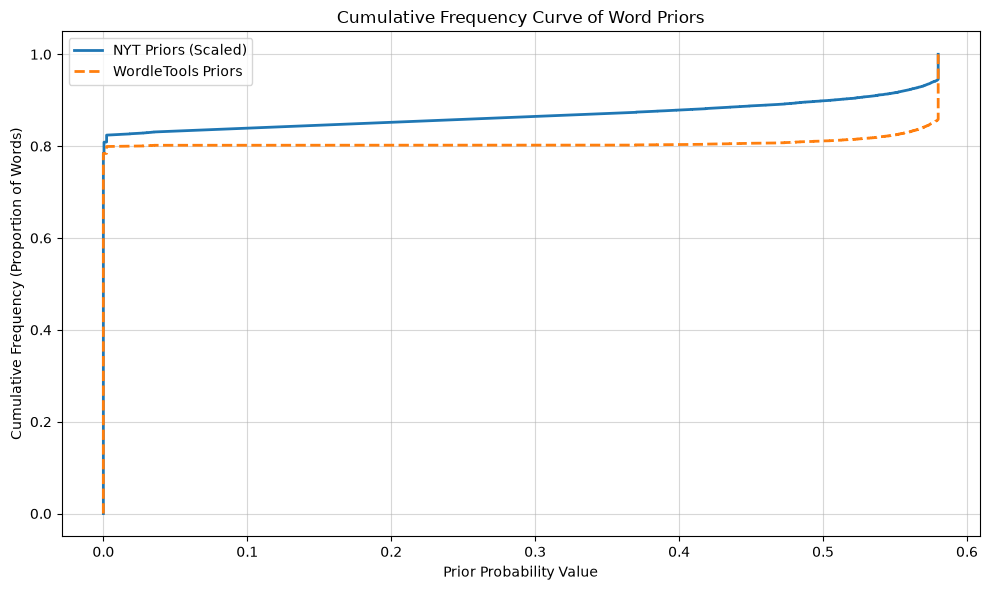

In [6]:
import matplotlib.pyplot as plt

# 1. Calculate non-zero counts
# We check for values strictly greater than 0
nyt_non_zero = (df['prior_nyt_scaled'] > 0).sum()
wt_non_zero = (df['prior_wt'] > 0).sum()

print("=== NON-ZERO PRIORS SUMMARY ===")
print(f"NYT (scaled) non-zero priors: {nyt_non_zero}")
print(f"WordleTools non-zero priors: {wt_non_zero}")
print(f"Total words in dataset: {len(df)}")
print("===============================\n")

# 2. Prepare data for cumulative frequency curve
# Sort the arrays in ascending order to build the Cumulative Distribution Function (CDF)
nyt_sorted = np.sort(df['prior_nyt_scaled'])
wt_sorted = np.sort(df['prior_wt'])

# Calculate the cumulative probability/frequency (from >0.0 to 1.0)
cumulative_frequency = np.arange(1, len(df) + 1) / len(df)

# 3. Plot the cumulative frequency curves
plt.figure(figsize=(10, 6))

# Plot both distributions
plt.plot(nyt_sorted, cumulative_frequency, label='NYT Priors (Scaled)', linewidth=2)
plt.plot(wt_sorted, cumulative_frequency, label='WordleTools Priors', linewidth=2, linestyle='--')

# Formatting the plot
plt.title('Cumulative Frequency Curve of Word Priors')
plt.xlabel('Prior Probability Value')
plt.ylabel('Cumulative Frequency (Proportion of Words)')
plt.legend()
plt.grid(True, alpha=0.5)

# Optional: Add annotations or adjust axis limits if the zero-mass is visually overwhelming, 
# but showing the full 0-to-max range gives the most accurate representation of the data.
plt.tight_layout()
plt.show()

In [7]:
# 1. Load the unseen datasets
# Assuming the wordletools dataset (wt_df) and TOLERANCE (1e-4) are already in memory from previous cells.
unseen_nyt_df = pd.read_csv('../data/unseen_cleaned_priors.csv')

# 2. Merge datasets on the 'word' column
df_unseen = pd.merge(unseen_nyt_df, wt_df, on='word', suffixes=('_nyt', '_wt'))

# 3. Normalize the unseen NYT priors
df_unseen['prior_nyt_scaled'] = df_unseen['prior_nyt'] * 0.58

# 4. Check for equality within the existing floating-point tolerance bound
df_unseen['diff'] = np.abs(df_unseen['prior_nyt_scaled'] - df_unseen['prior_wt'])
df_unseen['is_equal'] = df_unseen['diff'] <= TOLERANCE

# 5. Calculate statistics
total_unseen_words = len(df_unseen)
equal_unseen_count = df_unseen['is_equal'].sum()
unequal_unseen_count = total_unseen_words - equal_unseen_count

# 6. Print the number of equal and unequal entries
print("=== UNSEEN PRIORS COMPARISON SUMMARY ===")
print(f"Total words analyzed: {total_unseen_words}")
print(f"Equal priors (within {TOLERANCE} tolerance): {equal_unseen_count}")
print(f"Unequal priors: {unequal_unseen_count}")
print("========================================")

=== UNSEEN PRIORS COMPARISON SUMMARY ===
Total words analyzed: 14855
Equal priors (within 0.0001 tolerance): 14855
Unequal priors: 0
